In [21]:
import pandas as pd
from scipy.io import wavfile
from egg_io import *
from fpca_preprocess import *
import matplotlib.pyplot as plt

all_data = pd.read_csv("voiceSauce.csv")
TIMEPOINT = 5

In [22]:
# savedRow = random_test_file(all_data)
# savedRow = random_test_file(all_data, filterLanguage = 'Hmong')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Zapotec/speaker1M_eM3.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 2/F3_srii33_01.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 2/F3_thuu_33_01.wav')
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 1/F1_dze_33_02 .wav')

# HIGH V1: (0.2057898)
savedRow = grabSpecificFile(all_data, 'egg_melt/Hmong/14e-tam-w.pmf')
# LOWWW V1: (-0.2040641)
# savedRow = grabSpecificFile(all_data, 'egg_melt/Bo/Village 2/F3_bi31_01.wav')

savedRow

speaker_id             Hmong_M14
speaker_number                14
speaker_sex                    M
language                   Hmong
language_variety     White Hmong
                        ...     
SQ2_SQ1                    1.045
SQ4_SQ3                    3.539
ratio                      0.296
LPhon               Hmong-Creaky
SQ                      0.295281
Name: 2224, Length: 80, dtype: object

In [23]:
# samplerate, data = wavfile.read(filepath(savedRow))
# startSample, endSample = sampleEndpoints(savedRow.segment_start, savedRow.segment_end, samplerate, timepoint = TIMEPOINT)
# egg = data[startSample:endSample]

egg, samplerate = loadFile(savedRow, TIMEPOINT)

In [24]:
# new thing! low pass!
egg = lowpass(egg, samplerate, 722)

In [25]:
peaks = pitchmark(egg, samplerate, savedRow.strF0)
threshold = find_threshold(egg, peaks)

<function matplotlib.pyplot.show(close=None, block=None)>

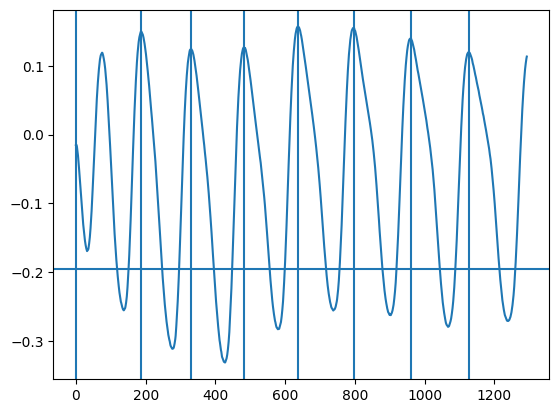

In [26]:
plt.plot(egg)
for peak in peaks:
    plt.axvline(peak)
plt.axhline(threshold)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

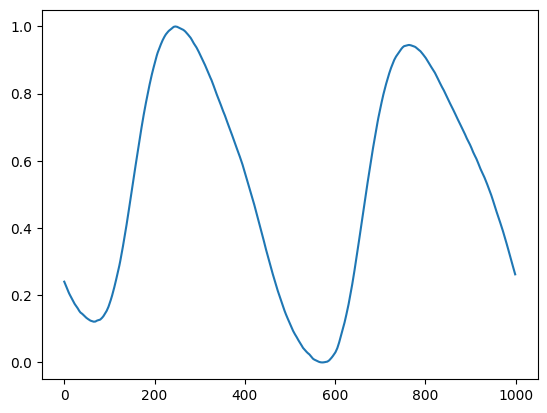

In [27]:
clipped_egg = clip_egg(egg, threshold, peaks)
# TODO: we're getting list index out of range here, in low-F0 cases. look into that if it happens a bunch!
# TODO: also, a lot of the gujarati data is reeeally choppy, i'd look into ways of making this algorithm more robust!
# ^ further, sometimes even in other languages the threshold is too low. raising it would come at the cost of research backing, but might give us more pages!!!
final = normalize_egg(clipped_egg)

plt.plot(final)
plt.show